In [1]:
# Import the Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("../data/HousingDataset.csv")

#### Data Understanding

In [3]:
# Shape of the dataset
df.shape

(545, 13)

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

#### Missing Values + Duplicates

In [9]:
# Checking the Null Values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
# Checking the duplicates
df.duplicated().sum()

np.int64(0)

#### Univariate Analysis

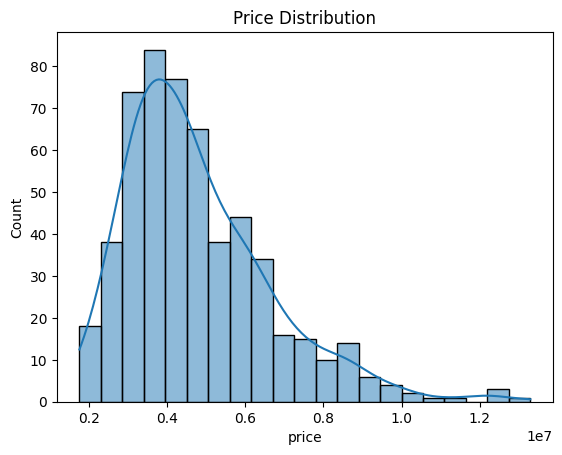

In [11]:
# Target Variable (Price)
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

In [12]:
df['price'].skew()

np.float64(1.2122388370279802)

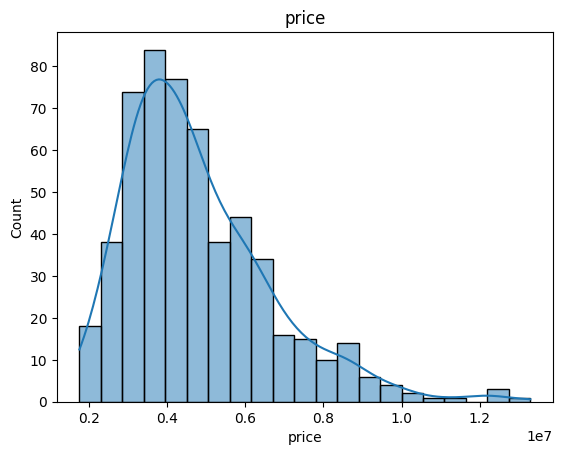

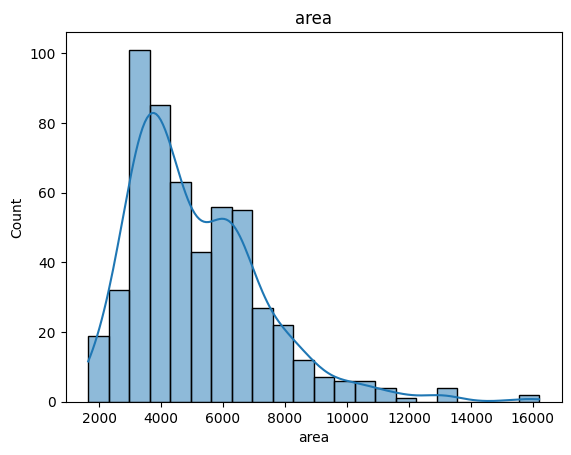

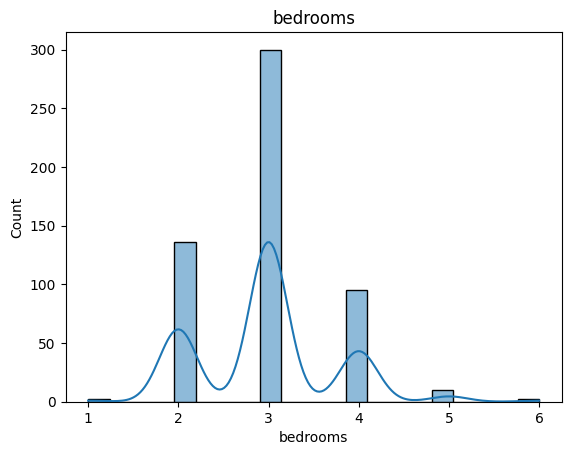

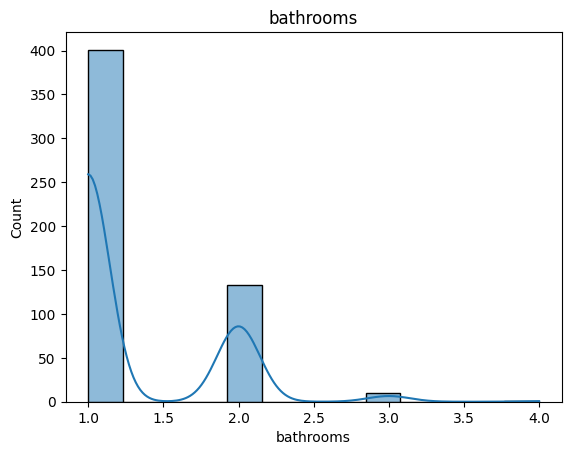

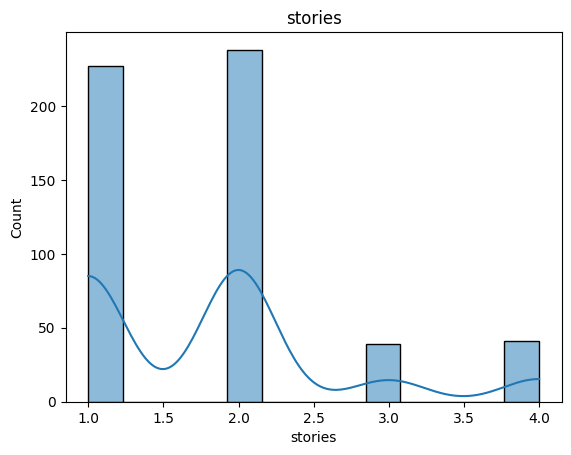

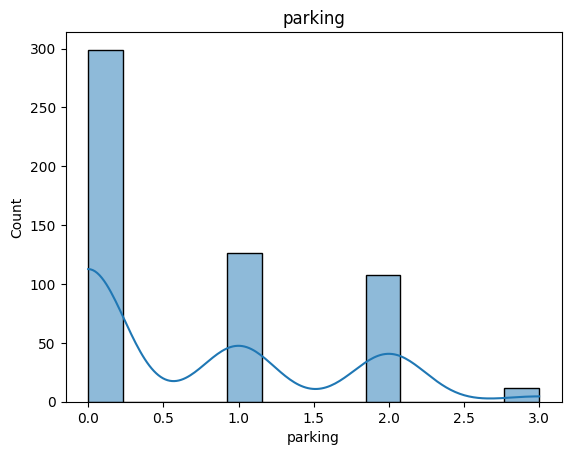

In [13]:
# Numerical Features
for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

mainroad
yes    468
no      77
Name: count, dtype: int64


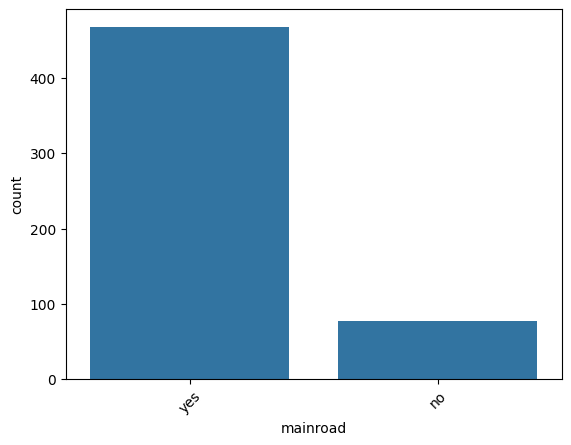

guestroom
no     448
yes     97
Name: count, dtype: int64


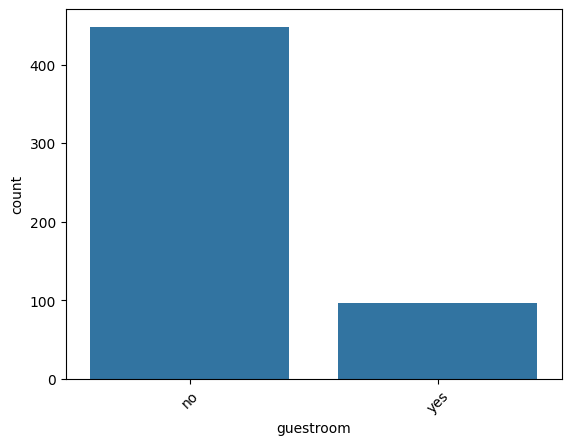

basement
no     354
yes    191
Name: count, dtype: int64


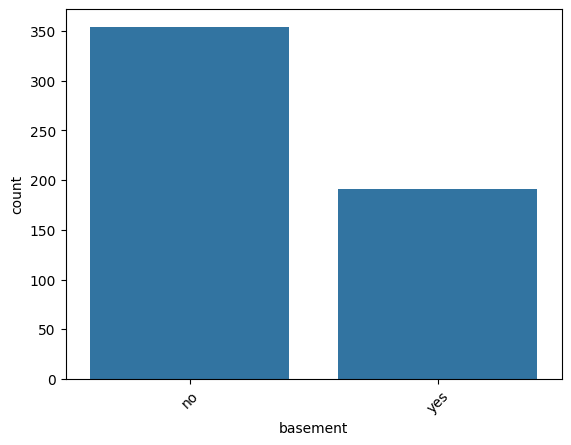

hotwaterheating
no     520
yes     25
Name: count, dtype: int64


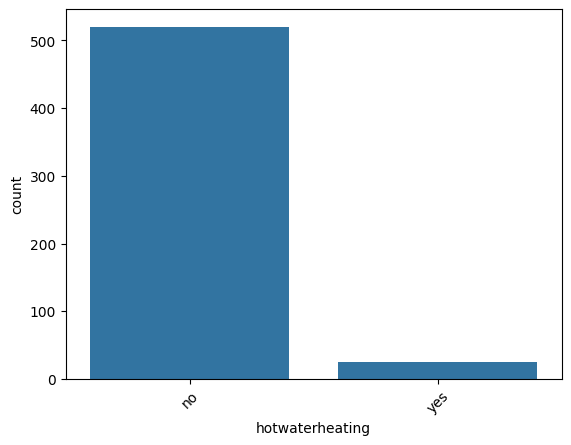

airconditioning
no     373
yes    172
Name: count, dtype: int64


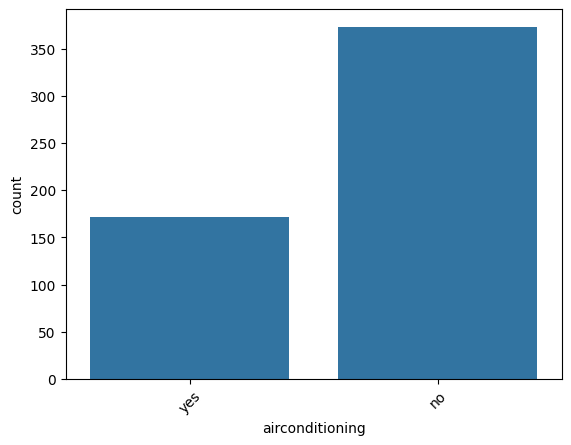

prefarea
no     417
yes    128
Name: count, dtype: int64


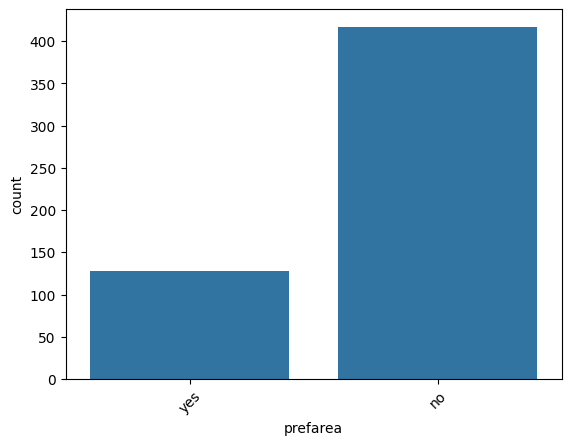

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


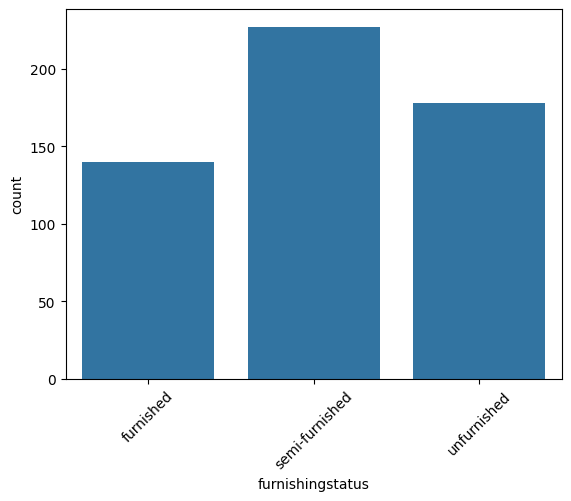

In [14]:
# Categorical Features
for col in df.select_dtypes(include=['object']).columns:
    print(df[col].value_counts())
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

#### Bivariate Analysis

In [15]:
# Numerical VS Price
num_cols = df.select_dtypes(include=['int64','float64']).columns

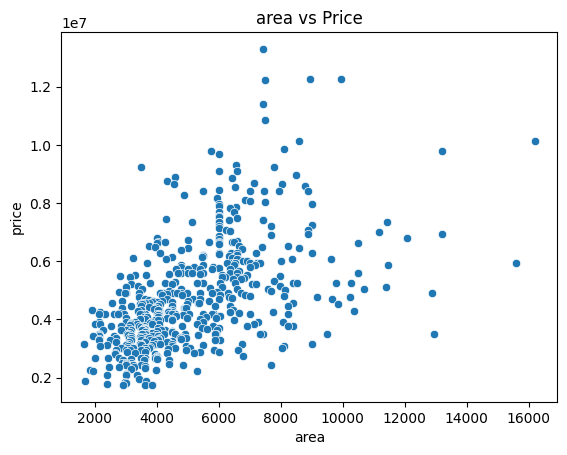

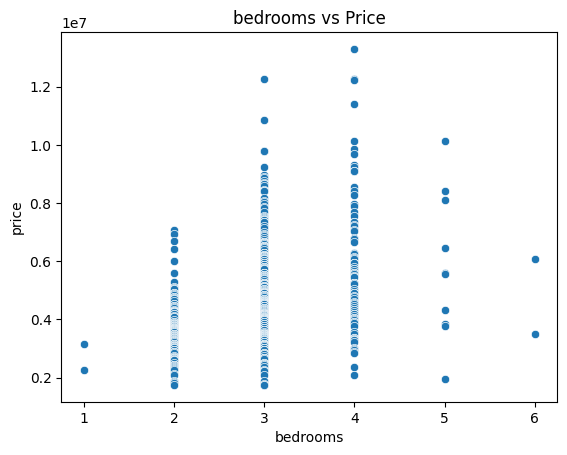

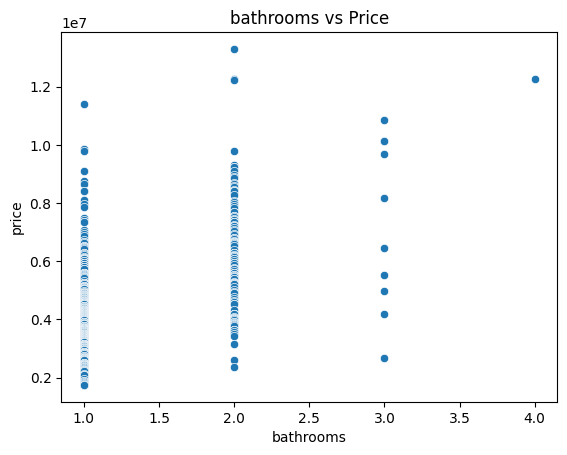

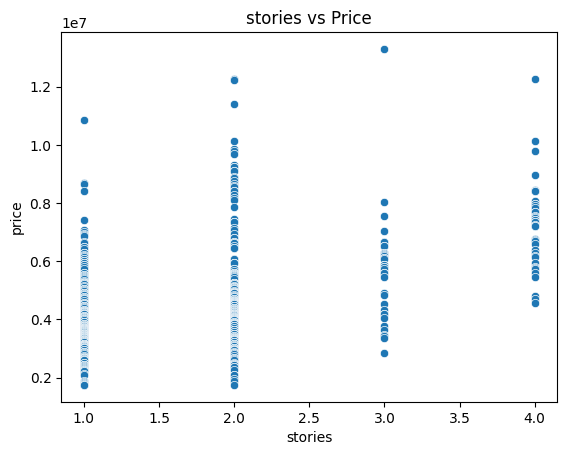

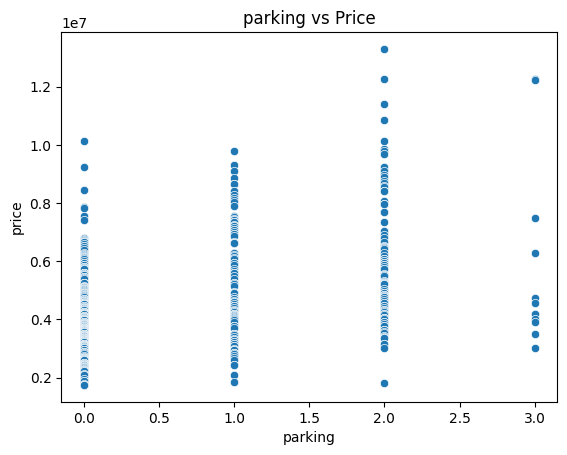

In [16]:
for col in num_cols:
    if col != 'price':
        sns.scatterplot(x=df[col], y=df['price'])
        plt.title(f"{col} vs Price")
        plt.show()

In [17]:
# Categorical vs Price
cat_cols = df.select_dtypes(include=['object']).columns

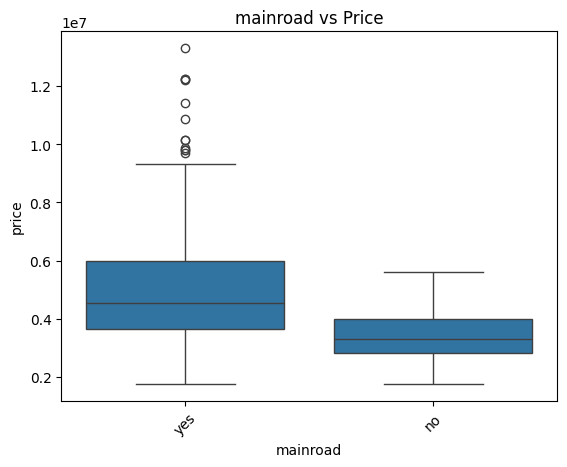

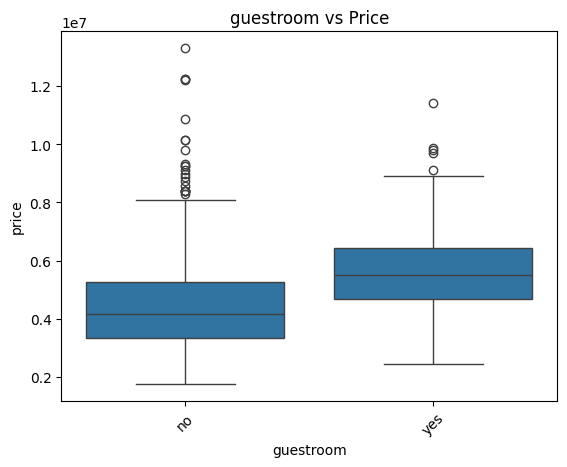

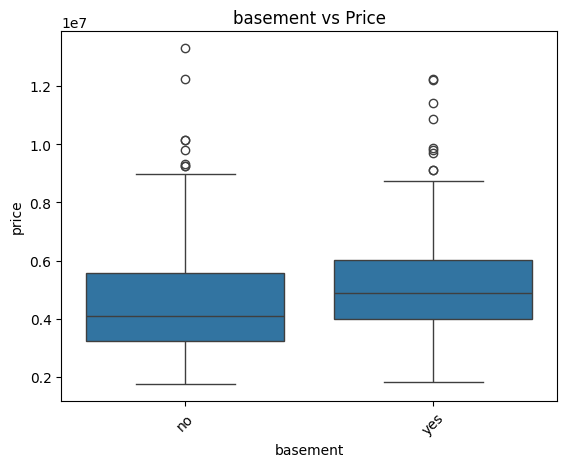

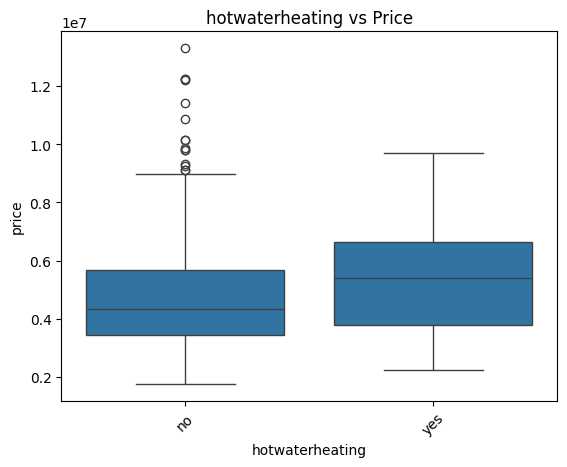

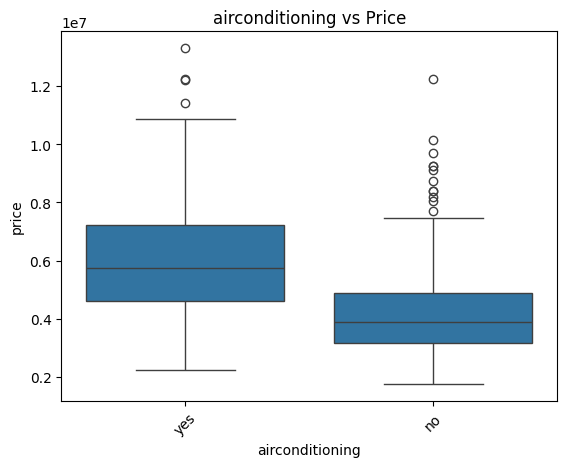

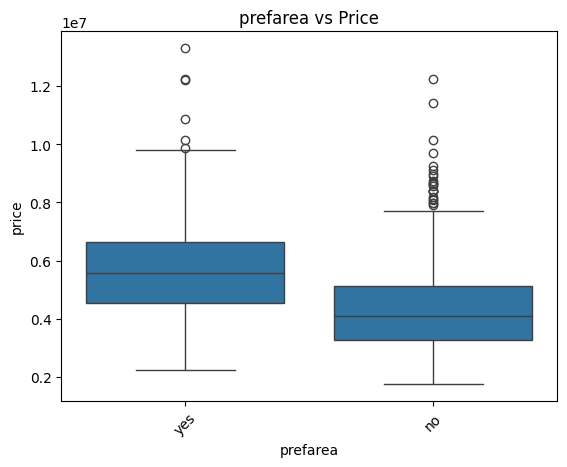

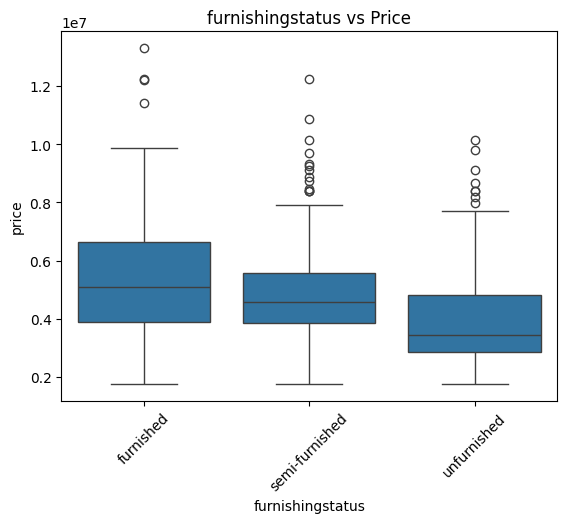

In [18]:
for col in cat_cols:
    sns.boxplot(x=df[col], y=df['price'])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Price")
    plt.show()

#### Correlation Matrix

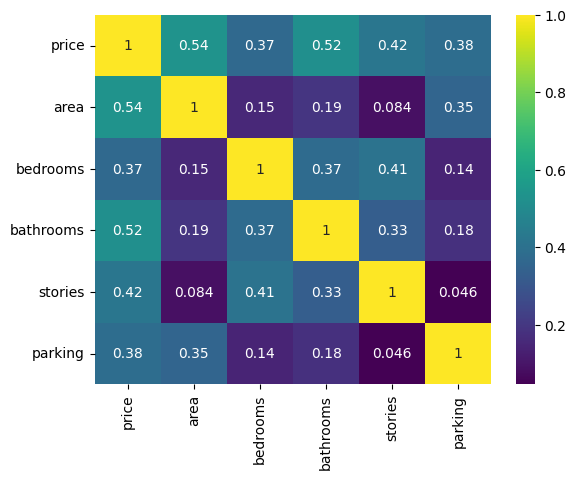

In [19]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='viridis')
plt.show()

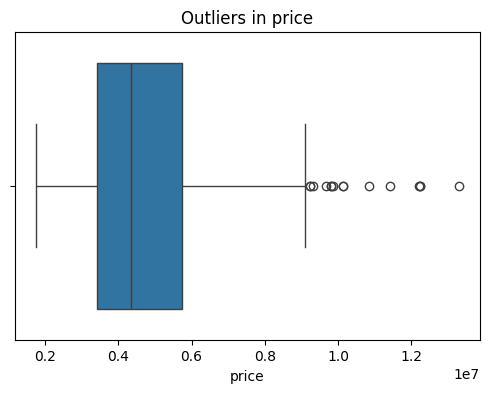

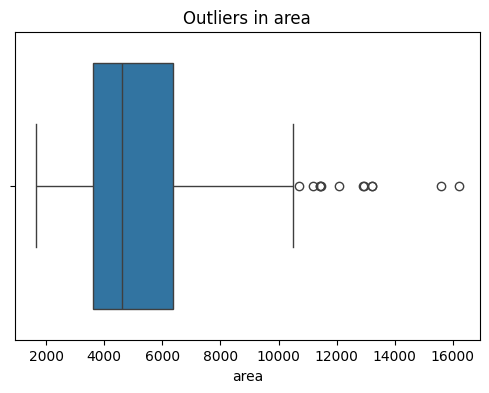

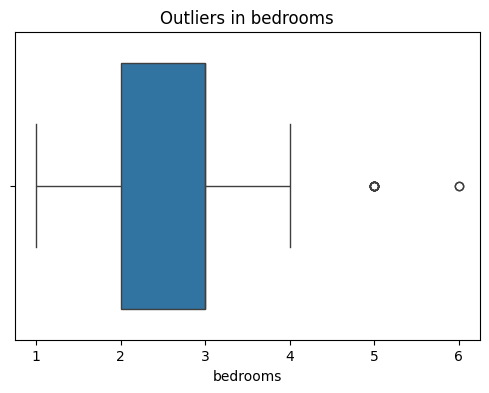

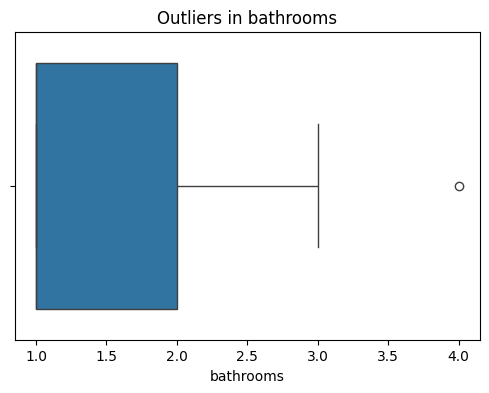

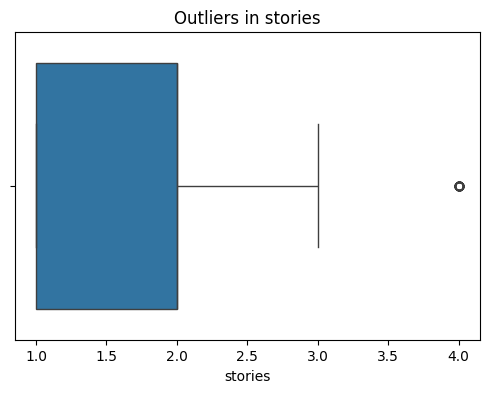

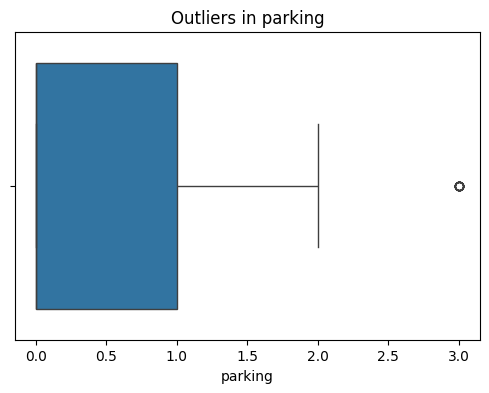

In [20]:
# Outlier Detection
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

#### Outlier Removal

In [21]:
from scipy.stats import zscore

In [22]:
num_cols

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [23]:
z_scores = df[num_cols].apply(zscore)

In [ ]:
df_clean = df[(z_scores.abs() < 4).all(axis=1)]

In [25]:
print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (545, 13)
After Removing Outliers: (538, 13)
